In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# -------------------- Settings --------------------
n_files = 20

# Root folder and subfolders for each method
root = "/scratch/g/chlin/Yushu/results/Comparison_methods/"
method_dirs = {
    "scAce":   "/scace/4_clus_mix",
    "ADClust": "/adclust/4_clus_mix",
    "scVI":    "/scvi/4_clus_mix",
}

# -------------------- Collect ARI / NMI --------------------
aris = {}
nmis = {}

for method, subdir in method_dirs.items():
    base_path = f"{root}{subdir}/"
    ari_list, nmi_list = [], []

    for i in range(1, n_files + 1):
        file = f"{base_path}results_sim_{i}.npz"
        data = np.load(file, allow_pickle=True)

        # If ARI/NMI already scalars, np.mean() does nothing harmful.
        ari_val = np.mean(np.array(data["ARI"]))
        nmi_val = np.mean(np.array(data["NMI"]))

        ari_list.append(ari_val)
        nmi_list.append(nmi_val)

    aris[method] = ari_list
    nmis[method] = nmi_list

# DMVAE: 20 perfect runs
aris["DMVAE"] = [1.0] * n_files
nmis["DMVAE"] = [1.0] * n_files


In [19]:
# scdac
base_path = "/scratch/g/chlin/Yushu/scDAC/scDAC/data/sim_result/"
ari_list, nmi_list = [], []

for i in range(1, n_files + 1):
    file = f"{base_path}sim{i}/scdac.npz"
    data = np.load(file, allow_pickle=True)

    # If ARI/NMI already scalars, np.mean() does nothing harmful.
    ari_val = np.mean(np.array(data["ARI"]))
    nmi_val = np.mean(np.array(data["NMI"]))

    ari_list.append(ari_val)
    nmi_list.append(nmi_val)

aris["scDAC"] = ari_list
nmis["scDAC"]  = nmi_list

In [20]:
# scGNN
data = pd.read_csv("/scratch/g/chlin/Yushu/results/Comparison_methods/scgnn/4_clus/scgnn_4clus_ari_nmi_summary.csv")
# if you already loaded df
aris["scGNN"] = data["ARI"].astype(float).tolist()
nmis["scGNN"]  = data["NMI"].astype(float).tolist()

In [21]:
aris

{'scAce': [0.61536,
  1.0,
  0.60334,
  0.61574,
  0.60277,
  0.60631,
  0.61976,
  1.0,
  0.61047,
  0.60704,
  0.60753,
  1.0,
  1.0,
  0.62721,
  1.0,
  0.60251,
  0.60282,
  1.0,
  0.60319,
  0.62308],
 'ADClust': [0.9979,
  0.9662,
  0.9941,
  0.9836,
  0.9936,
  0.9851,
  0.9936,
  0.9941,
  0.9952,
  0.9985,
  0.9788,
  0.984,
  0.9594,
  0.9958,
  0.9877,
  0.9687,
  0.9925,
  0.9883,
  0.9973,
  0.9957],
 'scVI': [0.9904,
  0.9925,
  0.9888,
  0.9893,
  0.9909,
  0.991,
  0.9909,
  0.9883,
  0.9414,
  0.9823,
  0.9846,
  0.9925,
  0.9899,
  0.9867,
  0.9847,
  0.983,
  0.9861,
  0.9936,
  0.9926,
  0.8922],
 'DMVAE': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'scDAC': [0.7494956766177647,
  0.5184855928328631,
  0.46191400698586405,
  0.6027319761544363,
  0.4692615764837464,
  0.5590697029489121,
  0.7108664900087083,
  0.48254335989634106,
  0.5358169383967928,
  0.5719544771906

In [22]:
# -------------------- Long-format DataFrame --------------------
rows = []
method_order = ["scVI", "scGNN", "ADClust", "scAce", "scDAC", "DMVAE"]  

for method in method_order:
    for ari_val, nmi_val in zip(aris[method], nmis[method]):
        rows.append({"Method": method, "ARI": ari_val, "NMI": nmi_val})

df = pd.DataFrame(rows)

/tmp/ipykernel_524227/1571064913.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


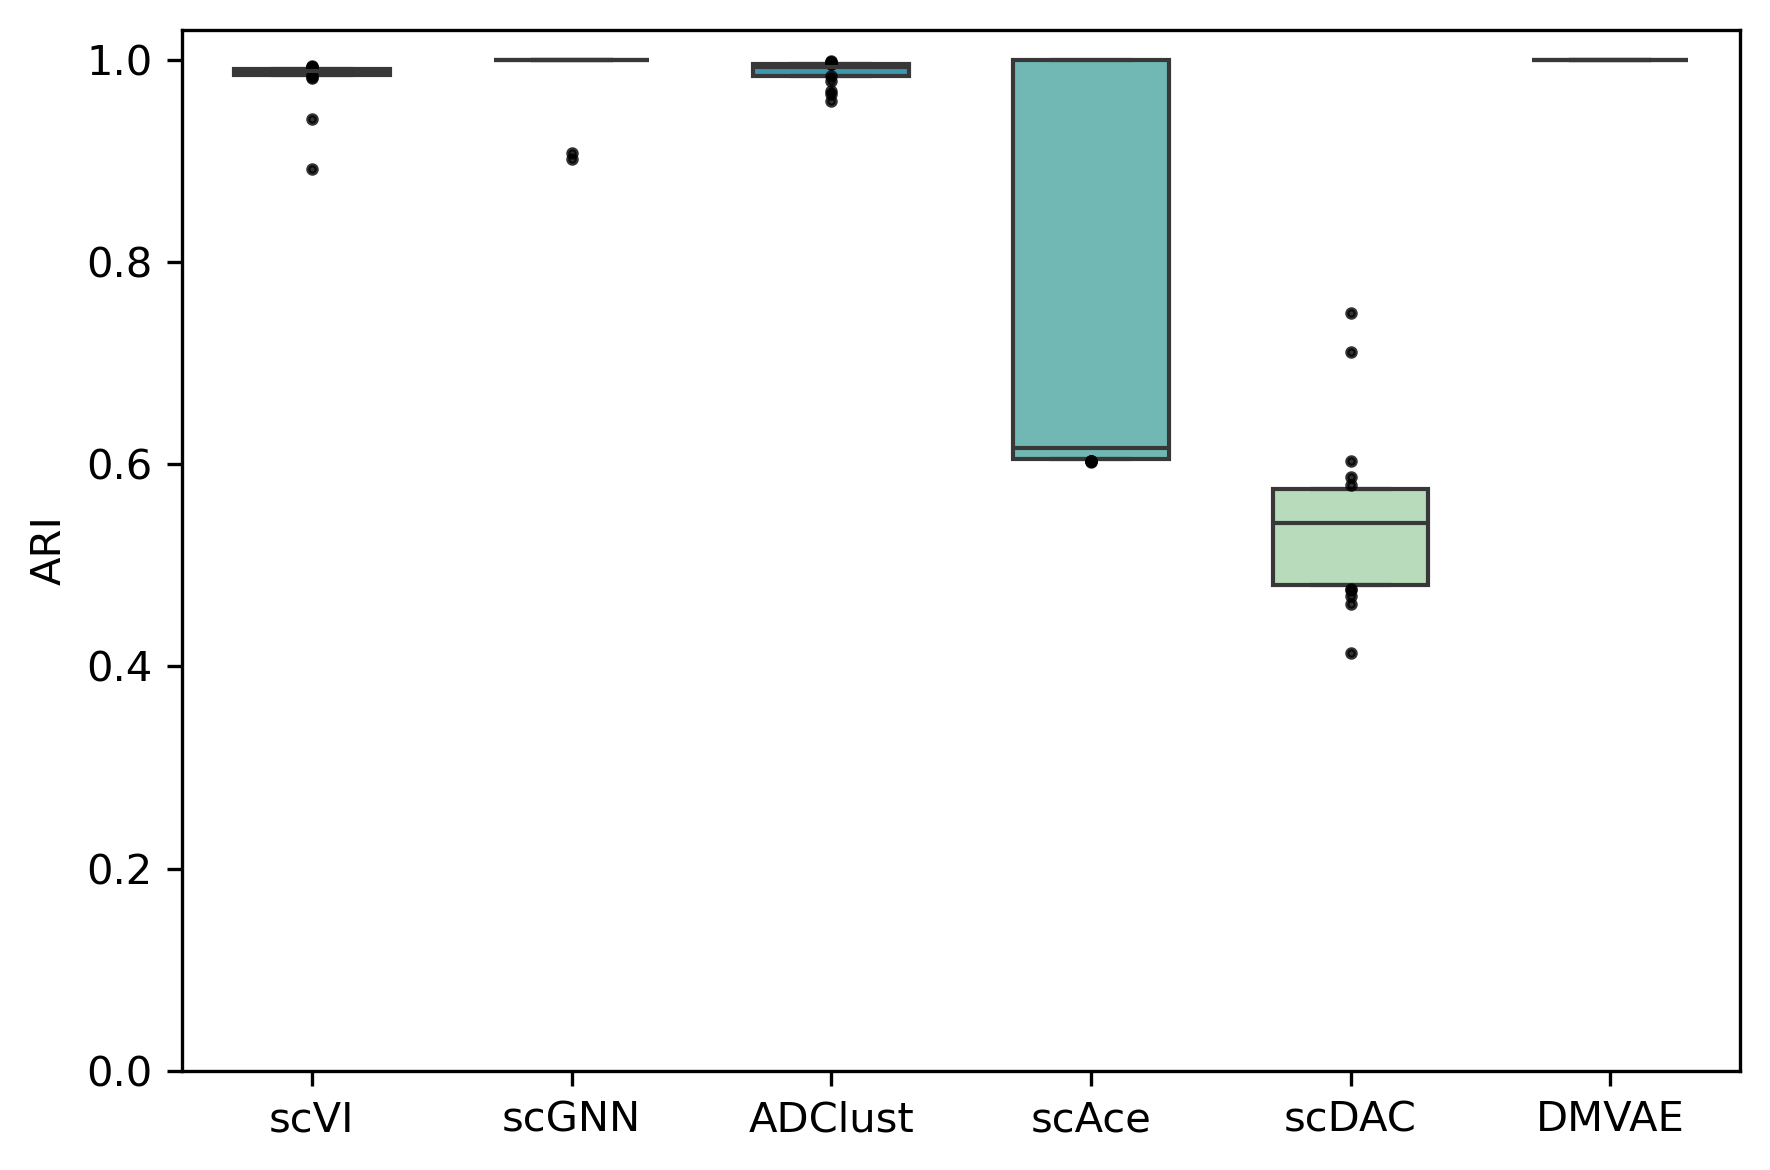

In [23]:
# -------------------- Boxplot for ARI --------------------
plt.figure(figsize=(6, 4), dpi=300)
sns.boxplot(
    data=df,
    x="Method",
    y="ARI",
    palette="YlGnBu_r",
    width=0.6,
    showfliers=True,
# Hide whiskers + caps
    whis=0,                  # whisker length = 0 → removes min/max whiskers
    #showcaps=False,

    # Outlier style
    flierprops=dict(
        #marker='o',
        markersize=2,
        markerfacecolor='black',
        markeredgecolor='black',
        alpha=0.8
    )
)
plt.xlabel("")
plt.ylim(0, None)
plt.tight_layout()
plt.savefig("/scratch/g/chlin/Yushu/Aim1/Plots/ari_boxplot.png")
plt.show()


/tmp/ipykernel_524227/1413126101.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


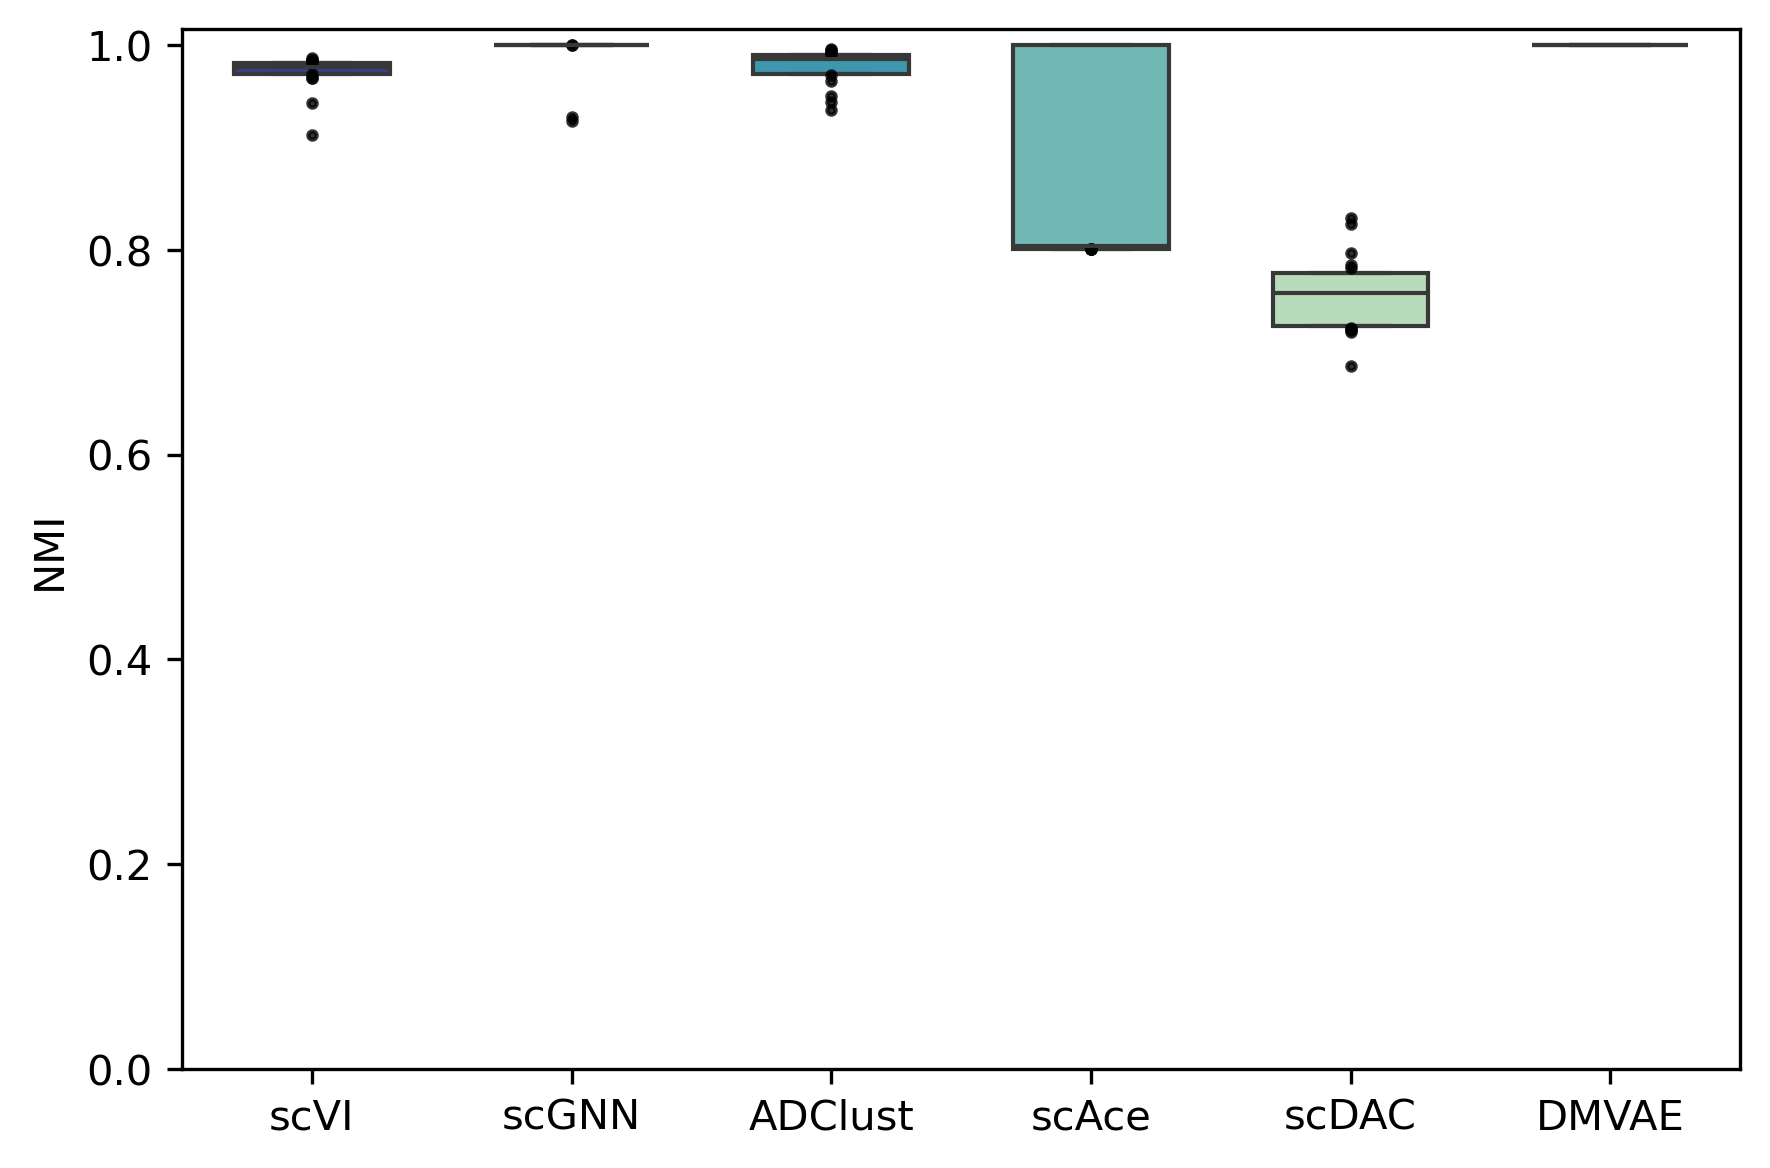

In [24]:
# -------------------- Boxplot for NMI --------------------
plt.figure(figsize=(6, 4), dpi=300)
sns.boxplot(
    data=df,
    x="Method",
    y="NMI",
    palette="YlGnBu_r",
    width=0.6,
    showfliers=True,
# Hide whiskers + caps
    whis=0,                  # whisker length = 0 → removes min/max whiskers
    #showcaps=False,
    # Outlier style
    flierprops=dict(
        #marker='o',
        markersize=2,
        markerfacecolor='black',
        markeredgecolor='black',
        alpha=0.8
    )
)
plt.xlabel("")
plt.ylim(0, None)
plt.tight_layout()
plt.savefig("/scratch/g/chlin/Yushu/Aim1/Plots/nmi_boxplot.png")
plt.show()